# Week 1-2: Data Cleaning & Exploratory Data Analysis
## Dataset: Online Retail

### Import Libraries
Importing Pandas for data manipulation, NumPy for numerical operations, 
and Matplotlib/Seaborn for data visualization.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Dataset Understanding

Loading the dataset and exploring its basic structure: shape, data types, 
numerical vs categorical variables, and potential primary key.

In [3]:
# 1. Charger le dataset
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

# 2. Afficher les premières lignes
print(df.head())

# 3. Identifier la structure
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print("\nTypes de données :")
print(df.dtypes)

# Variables numériques vs catégorielles
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables numériques : {num_cols}")
print(f"Variables catégorielles : {cat_cols}")

# Clé primaire potentielle
print(f"\nInvoiceNo uniques : {df['InvoiceNo'].nunique()}")
print(f"StockCode uniques : {df['StockCode'].nunique()}")
print(f"Combinaison InvoiceNo+StockCode unique : {df.duplicated(subset=['InvoiceNo','StockCode']).sum() == 0}")

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
Nombre de lignes : 541909
Nombre de colonnes : 8

Types de données :
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
Custom

**Dataset description:** This dataset contains e-commerce transactions from a 
UK-based online retailer, covering the period from December 2010 to December 2011. 
Each row represents one product line within a customer invoice. The combination 
of `InvoiceNo` and `StockCode` is not a strictly unique key, since the same 
product can appear more than once within the same invoice — so no natural 
unique primary key exists in this dataset.

## Task 2: Data Cleaning

### Missing Values
Identifying columns with missing values and counting them.

In [4]:
# Identifier + compter
missing = df.isnull().sum()
print(missing[missing > 0])

Description      1454
CustomerID     135080
dtype: int64


**Handling missing values:**
- `Description` (1,454 missing): filled with "Unknown", since the product 
  cannot be reliably inferred from the StockCode alone.
- `CustomerID` (135,080 missing, ~25% of rows): flagged with -1 instead of 
  removed, since these rows remain valid for product/country/time analysis 
  and are only excluded from customer-level analysis.

In [5]:
# Description manquante : on ne peut pas deviner le produit à partir du StockCode
# de façon fiable -> on remplace par "Unknown"
df['Description'] = df['Description'].fillna('Unknown')

# CustomerID manquant : on ne peut pas inventer un client.
# On garde une copie complète pour l'EDA produits/pays,
# mais on crée un sous-jeu de données à part pour toute analyse par client.
df['CustomerID'] = df['CustomerID'].fillna(-1)  # -1 = "client non identifié"

### Duplicate Records
Identifying and removing exact duplicate rows.

In [6]:
dupes = df.duplicated().sum()
print(f"Doublons trouvés : {dupes}")

df = df.drop_duplicates()
print(f"Nouveau nombre de lignes : {df.shape[0]}")

Doublons trouvés : 5268
Nouveau nombre de lignes : 536641


### Standardization
Converting `InvoiceDate` to proper datetime format, standardizing text case 
for `Description` and `Country`, renaming columns to snake_case, and fixing 
data types (`CustomerID` to integer).

In [7]:
# Dates -> vrai format datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

# Texte -> casse uniforme
df['Description'] = df['Description'].str.strip().str.upper()
df['Country'] = df['Country'].str.strip().str.title()

# Noms de colonnes -> snake_case cohérent
df.columns = ['invoice_no', 'stock_code', 'description', 'quantity',
              'invoice_date', 'unit_price', 'customer_id', 'country']

# Types de données
df['customer_id'] = df['customer_id'].astype(int)

### Data Validation
Checking for invalid values: negative quantities (returns), cancelled orders 
(invoices starting with "C"), and invalid unit prices (≤ 0).

In [8]:
# Quantités négatives = retours/annulations
neg_qty = (df['quantity'] < 0).sum()
print(f"Quantités négatives : {neg_qty}")

# Factures annulées (commencent par 'C')
cancelled = df['invoice_no'].astype(str).str.startswith('C').sum()
print(f"Factures annulées : {cancelled}")

# Prix unitaire <= 0 (probable erreur ou ligne non commerciale, ex: "Adjustment")
bad_price = (df['unit_price'] <= 0).sum()
print(f"Prix invalides : {bad_price}")

# Décision : on sépare les annulations dans un dataset à part,
# et on garde le dataset principal propre pour les ventes réelles
df_cancelled = df[df['invoice_no'].astype(str).str.startswith('C')]
df_clean = df[~df['invoice_no'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['unit_price'] > 0]
df_clean = df_clean[df_clean['quantity'] > 0]

print(f"Dataset final propre : {df_clean.shape[0]} lignes")

Quantités négatives : 10587
Factures annulées : 9251
Prix invalides : 2512
Dataset final propre : 524878 lignes


### Cleaning Summary

In [9]:
summary = pd.DataFrame({
    'Issue Found': ['Missing Values (Description)', 'Missing Values (CustomerID)',
                     'Duplicates', 'Invalid Quantity/Price', 'Cancelled Orders', 'Standardization'],
    'Action Taken': ['Filled with "Unknown"', 'Flagged with -1, excluded from customer analysis',
                      'Removed (5,268 rows)', 'Removed from clean dataset',
                      'Separated into own dataframe', 'Dates, text case, column names, dtypes fixed']
})
print(summary)

                    Issue Found  \
0  Missing Values (Description)   
1   Missing Values (CustomerID)   
2                    Duplicates   
3        Invalid Quantity/Price   
4              Cancelled Orders   
5               Standardization   

                                       Action Taken  
0                             Filled with "Unknown"  
1  Flagged with -1, excluded from customer analysis  
2                              Removed (5,268 rows)  
3                        Removed from clean dataset  
4                      Separated into own dataframe  
5      Dates, text case, column names, dtypes fixed  


### Export Cleaned Dataset
Saving the cleaned dataset to CSV for further analysis (Task 3-5) and submission.

In [10]:
df_clean.to_csv('OnlineRetail_cleaned.csv', index=False)

## Task 3: Exploratory Data Analysis (EDA)

Now that the dataset is cleaned, we generate summary statistics and explore 
key patterns in the data.

### Summary Statistics
Descriptive statistics (mean, median, min, max, standard deviation) for all 
numerical columns.

In [14]:
# Créer une colonne Revenue (utile pour plusieurs analyses)
df_clean['revenue'] = df_clean['quantity'] * df_clean['unit_price']

# Statistiques descriptives
summary_stats = df_clean[['quantity', 'unit_price', 'revenue']].describe()
print(summary_stats)

            quantity     unit_price        revenue
count  524878.000000  524878.000000  524878.000000
mean       10.616600       3.922573      20.275399
std       156.280031      36.093028     271.693566
min         1.000000       0.001000       0.001000
25%         1.000000       1.250000       3.900000
50%         4.000000       2.080000       9.920000
75%        11.000000       4.130000      17.700000
max     80995.000000   13541.330000  168469.600000


### Analysis 1: Top-Selling Products (by Quantity)

In [15]:
top_products = df_clean.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: quantity, dtype: int64


### Analysis 2: Highest Revenue-Generating Countries

In [16]:
revenue_by_country = df_clean.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
print(revenue_by_country)

country
United Kingdom    9001744.094
Netherlands        285446.340
Eire               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64


### Analysis 3: Monthly Sales Trend

In [17]:
df_clean['invoice_month'] = df_clean['invoice_date'].dt.to_period('M')
monthly_sales = df_clean.groupby('invoice_month')['revenue'].sum()
print(monthly_sales)

invoice_month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: revenue, dtype: float64


### Analysis 4: Most Purchased Products (by Number of Orders)

In [18]:
most_purchased = df_clean.groupby('description')['invoice_no'].nunique().sort_values(ascending=False).head(10)
print(most_purchased)

description
WHITE HANGING HEART T-LIGHT HOLDER    2256
JUMBO BAG RED RETROSPOT               2089
REGENCY CAKESTAND 3 TIER              1988
PARTY BUNTING                         1685
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1385
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: invoice_no, dtype: int64


### Analysis 5: Customer Purchasing Behavior (Top Customers by Spend)

In [19]:
# On exclut les clients non identifiés (customer_id = -1)
known_customers = df_clean[df_clean['customer_id'] != -1]
top_customers = known_customers.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

avg_orders_per_customer = known_customers.groupby('customer_id')['invoice_no'].nunique().mean()
print(f"\nAverage number of orders per customer: {avg_orders_per_customer:.2f}")

customer_id
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: revenue, dtype: float64

Average number of orders per customer: 4.27


## Task 4: Data Visualization

At least 5 visualizations, each with a title, axis labels, and a short 
explanation of the finding.

### Visualization 1: Top 10 Best-Selling Products (Bar Chart)

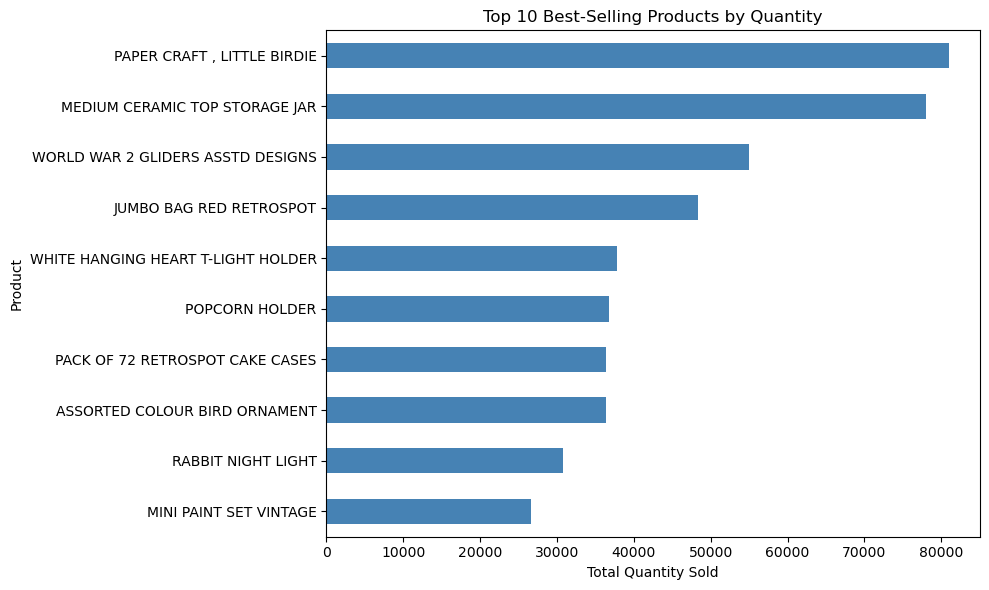

In [20]:
plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** A small number of products dominate total sales volume, 
suggesting a concentrated demand pattern rather than evenly distributed sales 
across the catalog.

### Visualization 2: Revenue by Top 10 Countries (Bar Chart)

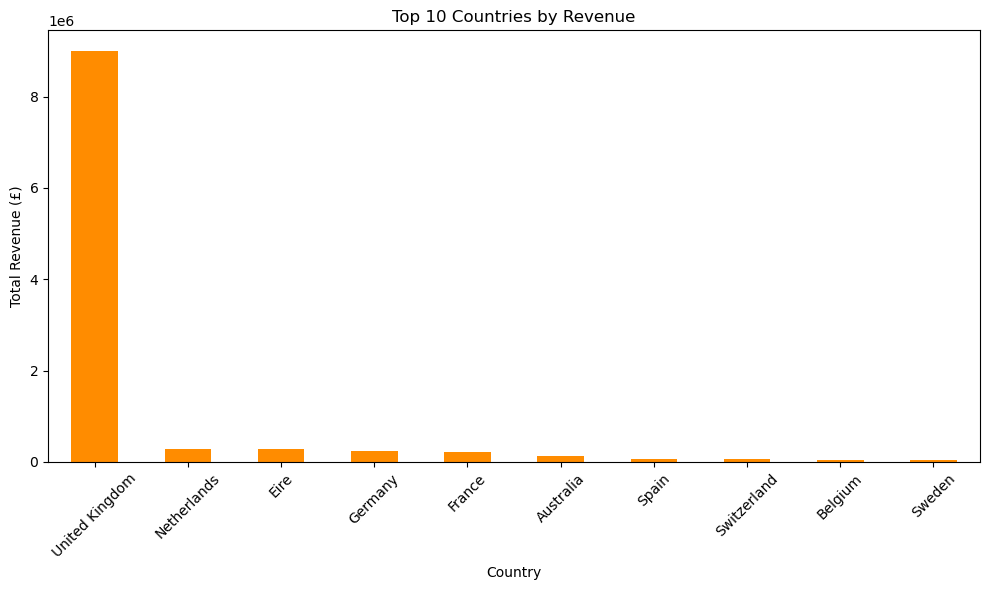

In [21]:
plt.figure(figsize=(10,6))
revenue_by_country.plot(kind='bar', color='darkorange')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** The United Kingdom generates the vast majority of revenue, 
reflecting the retailer's primarily domestic customer base.

### Visualization 3: Monthly Sales Trend (Line Chart)

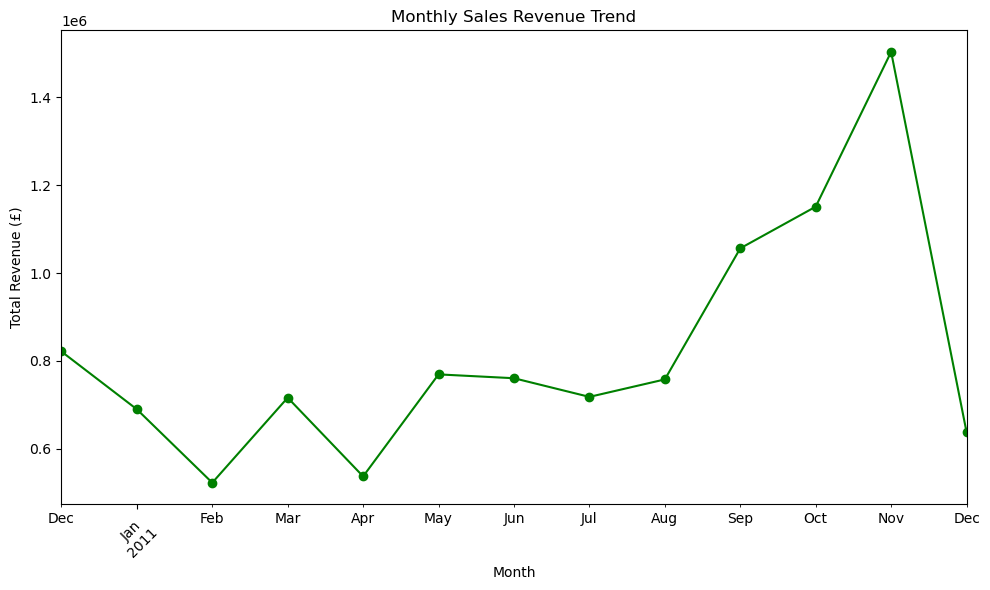

In [22]:
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** Sales show a clear upward trend toward the end of the year, 
likely driven by seasonal/holiday shopping.

### Visualization 4: Distribution of Order Quantities (Histogram)

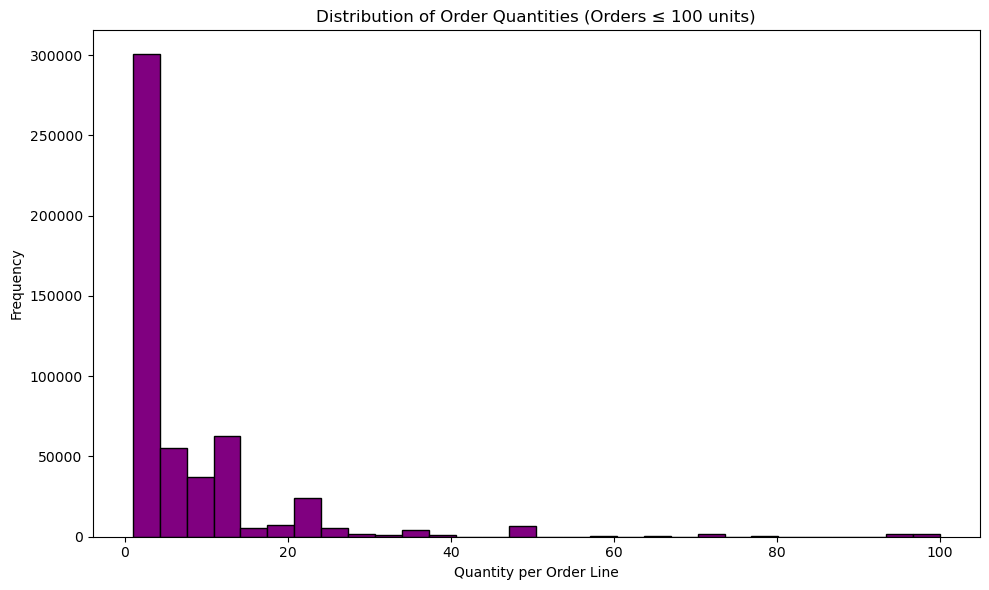

In [26]:
plt.figure(figsize=(10,6))
qty_filtered = df_clean[df_clean['quantity'] <= 100]['quantity']  # on filtre d'abord
plt.hist(qty_filtered, bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Order Quantities (Orders ≤ 100 units)')
plt.xlabel('Quantity per Order Line')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Finding:** Most order lines involve small quantities (under 20 units), 
with a long tail of bulk orders — typical of a mixed retail/wholesale customer base.

### Visualization 5: Revenue Share — UK vs Rest of World (Pie Chart)

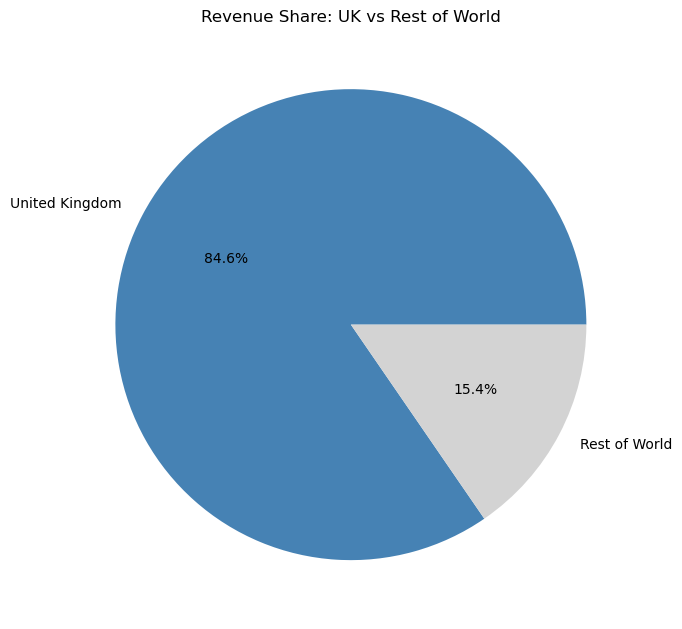

In [25]:
uk_revenue = df_clean[df_clean['country'] == 'United Kingdom']['revenue'].sum()
other_revenue = df_clean[df_clean['country'] != 'United Kingdom']['revenue'].sum()

plt.figure(figsize=(7,7))
plt.pie([uk_revenue, other_revenue], labels=['United Kingdom', 'Rest of World'],
        autopct='%1.1f%%', colors=['steelblue', 'lightgray'])
plt.title('Revenue Share: UK vs Rest of World')
plt.tight_layout()
plt.show()

**Finding:** The UK accounts for a dominant share of total revenue, confirming 
the retailer's strong reliance on its domestic market.

## Task 5: Key Insights

- **Insight 1 — Product concentration:** A small subset of products 
  (e.g. top 10) drives a disproportionately large share of total sales 
  volume (see Visualization 1). Inventory and marketing strategies could 
  prioritize these high-performing items.

- **Insight 2 — Market concentration:** The United Kingdom alone accounts 
  for the large majority of total revenue (see Visualizations 2 & 5). This 
  represents both a strength (strong core market) and a risk (limited 
  geographic diversification).

- **Insight 3 — Seasonality:** Monthly sales revenue increases significantly 
  toward the end of the year (see Visualization 3), suggesting strong 
  seasonal/holiday demand that could inform staffing and stock planning.

- **Insight 4 — Order size behavior:** Most transactions involve small 
  quantities per order line, with a long tail of bulk purchases 
  (see Visualization 4), indicating the presence of both individual 
  consumers and wholesale/business buyers within the same customer base.

- **Insight 5 — Customer data gap:** Approximately 25% of transactions have 
  no associated CustomerID, limiting the ability to perform full customer-level 
  analysis (e.g. retention, lifetime value) on a significant portion of the data.